<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 4 — Traductor Seq2Seq (EN → ES)

**Objetivos:**
- Replicar y extender el modelo traductor de clase usando un corpus más grande y secuencias más largas.
- Comparar distintas configuraciones de neuronas en las capas recurrentes.
- Generar al menos cinco ejemplos de traducción y analizar los resultados en detalle.


## 1. Imports y configuración

In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, time

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.21.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset

Se utiliza el mismo corpus `spa-eng` que en clase pero con **30 000 oraciones** (frente a las 10 000 del modelo base)
y longitudes máximas de **30 / 32 tokens** (frente a 20 / 22).
Esto expone al modelo a mayor variedad léxica y estructuras gramaticales más complejas.


In [3]:
if not os.path.exists('spa-eng'):
    os.system("curl -L -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("./spa-eng/spa.txt") as f:
    lines = f.read().split("\n")[:-1]

print(f"Total de pares disponibles en el corpus: {len(lines):,}")


  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed
 16  2.51M  16 416.0k   0      0 394.9k      0   00:06   00:01   00:05 412.5k

Total de pares disponibles en el corpus: 118,964


100  2.51M 100  2.51M   0      0  1.79M      0   00:01   00:01         412.5k


In [4]:
# ── Hiperparámetros globales ──────────────────────────────────────────────────
MAX_NUM_SENTENCES = 30_000   # 3× más que el modelo de clase
MAX_VOCAB_SIZE    = 10_000   # vocabulario más amplio
max_input_len     = 30       # secuencias más largas (clase usaba 20)
max_out_len       = 32       # (clase usaba 22)
EMBED_DIM         = 50       # dimensión GloVe
BATCH_SIZE        = 128

np.random.seed(42)
np.random.shuffle(lines)

input_sentences, output_sentences, output_sentences_inputs = [], [], []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if '\t' not in line:
        continue
    input_sentence, output = line.rstrip().split('\t')[:2]
    output_sentences.append(output + ' <eos>')
    output_sentences_inputs.append('<sos> ' + output)
    input_sentences.append(input_sentence)

print(f"Pares cargados: {len(input_sentences):,}")
print("\nEjemplo:")
print("  EN:", input_sentences[0])
print("  ES:", output_sentences[0])


Pares cargados: 30,000

Ejemplo:
  EN: How boring!
  ES: ¡Qué aburrimiento! <eos>


## 3. Tokenización y padding

In [5]:
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs   = input_tokenizer.word_index

output_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'
)
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq       = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

print(f"Vocabulario EN: {len(word2idx_inputs):,}")
print(f"Vocabulario ES: {len(word2idx_outputs):,}")
print(f"num_words_output (para capa Dense): {num_words_output:,}")
print(f"max_input_len={max_input_len}  max_out_len={max_out_len}")


Vocabulario EN: 8,088
Vocabulario ES: 13,858
num_words_output (para capa Dense): 10,000
max_input_len=30  max_out_len=32


In [6]:
encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding='post')

print("encoder_input_sequences shape:", encoder_input_sequences.shape)
print("decoder_input_sequences shape:", decoder_input_sequences.shape)


encoder_input_sequences shape: (30000, 30)
decoder_input_sequences shape: (30000, 32)


## 4. Pipeline de datos (tf.data)

In [7]:
def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size, num_classes):
    n = len(enc_seqs)

    def generator():
        for i in range(n):
            yield (
                enc_seqs[i].astype(np.int32),
                dec_in_seqs[i].astype(np.int32),
                dec_out_seqs[i].astype(np.int32),
            )

    def encode_one_hot(enc, dec_in, dec_out):
        y = tf.one_hot(dec_out, depth=num_classes)
        return (enc, dec_in), y

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(max_input_len,), dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
            tf.TensorSpec(shape=(max_out_len,),   dtype=tf.int32),
        )
    )
    ds = ds.map(encode_one_hot, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

val_split = 0.15
split_idx = int(len(encoder_input_sequences) * (1 - val_split))

train_ds = make_dataset(
    encoder_input_sequences[:split_idx],
    decoder_input_sequences[:split_idx],
    decoder_output_sequences[:split_idx],
    BATCH_SIZE, num_words_output
)
val_ds = make_dataset(
    encoder_input_sequences[split_idx:],
    decoder_input_sequences[split_idx:],
    decoder_output_sequences[split_idx:],
    BATCH_SIZE, num_words_output
)
print(f"Train: {split_idx:,} muestras | Val: {len(encoder_input_sequences) - split_idx:,} muestras")


Train: 25,500 muestras | Val: 4,500 muestras


I0000 00:00:1781742529.183358  332171 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21764 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:01:00.0, compute capability: 8.6


## 5. Embeddings preentrenados (GloVe)

Se utilizan embeddings GloVe de 50 dimensiones para el encoder (idioma fuente: inglés).
Los pesos se cargan como `trainable=False` para inicializar la capa de embedding con
representaciones semánticas ricas, evitando que el modelo tenga que aprenderlas desde cero.


In [8]:
def _is_valid_pickle(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(20)
        return b'<html' not in head.lower() and b'<!doctype' not in head.lower()
    except Exception:
        return False

_PKL_PATH = 'gloveembedding.pkl'
_FILE_ID  = '1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94'

if not os.path.exists(_PKL_PATH) or not _is_valid_pickle(_PKL_PATH):
    print("Descargando gloveembedding.pkl desde Google Drive...")
    if os.path.exists(_PKL_PATH):
        os.remove(_PKL_PATH)
    try:
        import gdown
        gdown.download(id=_FILE_ID, output=_PKL_PATH, quiet=False)
    except Exception:
        os.system(f"curl -L -o {_PKL_PATH} "
                  f"'https://drive.google.com/u/0/uc?id={_FILE_ID}&export=download&confirm=t'")
    if not _is_valid_pickle(_PKL_PATH):
        raise ValueError("El archivo descargado no es un pickle válido.")
    print("Descarga completada.")
else:
    print("gloveembedding.pkl ya disponible.")


Descargando gloveembedding.pkl desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94
From (redirected): https://drive.google.com/uc?id=1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94&confirm=t&uuid=5ebd6578-0201-409f-9d5a-0da7ff9980f4
To: /home/lilidl/tp4/gloveembedding.pkl
100%|██████████| 525M/525M [00:18<00:00, 27.7MB/s] 

Descarga completada.


In [9]:
def load_glove_embeddings(pkl_path):
    max_bytes = 2**28 - 1
    raw = bytearray()
    sz  = os.path.getsize(pkl_path)
    with open(pkl_path, 'rb') as f:
        for _ in range(0, sz, max_bytes):
            raw += f.read(max_bytes)
    embeddings = pickle.loads(raw)
    idx_array  = np.arange(embeddings.shape[0])
    word2idx   = dict(zip(embeddings['word'], idx_array))
    return embeddings, word2idx

def get_word_embedding(word, embeddings, word2idx, n_features=50):
    i = word2idx.get(word, -1)
    return embeddings[i]['embedding'] if i != -1 else np.zeros(n_features)

def build_embedding_matrix(word2idx_src, embeddings, word2idx_glove,
                            nb_words, embed_dim=50):
    matrix = np.zeros((nb_words, embed_dim))
    for word, i in word2idx_src.items():
        if i < nb_words:
            vec = get_word_embedding(word, embeddings, word2idx_glove, embed_dim)
            if vec is not None and len(vec) > 0:
                matrix[i] = vec
    return matrix

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs))
glove_embeddings, glove_word2idx = load_glove_embeddings(_PKL_PATH)
embedding_matrix = build_embedding_matrix(
    word2idx_inputs, glove_embeddings, glove_word2idx, nb_words, EMBED_DIM
)

zeros = np.sum(np.sum(embedding_matrix**2, axis=1) == 0)
total = embedding_matrix.shape[0]
print(f"Matriz de embeddings: {embedding_matrix.shape}")
print(f"Tokens sin cobertura GloVe: {zeros}/{total} ({100*zeros/total:.1f}%)")


/tmp/ipykernel_332171/2903135518.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  embeddings = pickle.loads(raw)


Matriz de embeddings: (8088, 50)
Tokens sin cobertura GloVe: 379/8088 (4.7%)


## 6. Arquitectura Seq2Seq

La arquitectura sigue el paradigma **encoder–decoder** con LSTM:

- **Encoder**: recibe la secuencia en inglés, produce un vector de contexto (estado `h` y `c`).
- **Decoder**: recibe `<sos>` + la secuencia en español (teacher forcing durante entrenamiento)
  y predice token a token condicionado en el contexto del encoder.

Las capas se construyen como objetos reutilizables para poder instanciar luego los modelos
de inferencia sin duplicar pesos.


In [10]:
def build_seq2seq(n_units, nb_words, embed_dim, embedding_matrix,
                  max_input_len, max_out_len, num_words_output):
    """Construye el modelo de entrenamiento y devuelve también las capas internas
       necesarias para armar los modelos de inferencia."""

    # ── Encoder ───────────────────────────────────────────────────────────────
    enc_inputs = Input(shape=(max_input_len,), name='encoder_inputs')

    enc_emb_layer = Embedding(
        input_dim=nb_words,
        output_dim=embed_dim,
        input_length=max_input_len,
        weights=[embedding_matrix],
        trainable=False,
        name='encoder_embedding'
    )
    enc_emb = Dropout(0.3, name='encoder_dropout')(enc_emb_layer(enc_inputs))

    enc_lstm_layer = LSTM(n_units, return_state=True, name='encoder_lstm')
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    enc_states = [state_h, state_c]

    # ── Decoder ───────────────────────────────────────────────────────────────
    dec_inputs = Input(shape=(max_out_len,), name='decoder_inputs')

    dec_emb_layer = Embedding(
        input_dim=num_words_output,
        output_dim=n_units,
        input_length=max_out_len,
        name='decoder_embedding'
    )
    dec_emb = Dropout(0.3, name='decoder_dropout')(dec_emb_layer(dec_inputs))

    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True,
                          name='decoder_lstm')
    dec_out, _, _  = dec_lstm_layer(dec_emb, initial_state=enc_states)

    dec_dense_layer = Dense(num_words_output, activation='softmax', name='decoder_dense')
    dec_out         = dec_dense_layer(dec_out)

    model = Model([enc_inputs, dec_inputs], dec_out,
                  name=f'seq2seq_u{n_units}')

    return model, enc_inputs, enc_emb_layer, enc_lstm_layer, dec_emb_layer, dec_lstm_layer, dec_dense_layer


def build_inference_models(enc_inputs, enc_emb_layer, enc_lstm_layer,
                            dec_emb_layer, dec_lstm_layer, dec_dense_layer,
                            n_units):
    """Instancia los modelos de encoder y decoder para inferencia greedy."""
    # Encoder inference
    enc_emb  = enc_emb_layer(enc_inputs)
    _, h, c  = enc_lstm_layer(enc_emb)
    enc_model = Model(enc_inputs, [h, c])

    # Decoder inference (un token por paso)
    dec_in_single = Input(shape=(1,),        name='dec_single_in')
    dec_h_in      = Input(shape=(n_units,),  name='dec_h_in')
    dec_c_in      = Input(shape=(n_units,),  name='dec_c_in')

    dec_emb_s            = dec_emb_layer(dec_in_single)
    dec_out_s, h_out, c_out = dec_lstm_layer(
        dec_emb_s, initial_state=[dec_h_in, dec_c_in]
    )
    dec_out_s = dec_dense_layer(dec_out_s)

    dec_model = Model(
        [dec_in_single, dec_h_in, dec_c_in],
        [dec_out_s, h_out, c_out]
    )
    return enc_model, dec_model


## 7. Entrenamiento y comparación de configuraciones

Se comparan **tres configuraciones** de neuronas en las capas LSTM:

| Config | n_units | Parámetros (aprox.) | Descripción |
|--------|---------|----------------------|-------------|
| Pequeño | 128 | ~3.5 M | Línea base reducida |
| Mediano | 256 | ~10 M | Configuración de clase |
| Grande  | 512 | ~35 M | Mayor capacidad |

Todos se entrenan con los mismos datos, callbacks y semilla para una comparación justa.


In [11]:
CONFIGS  = [128, 256, 512]   # n_units a comparar
EPOCHS   = 30
histories = {}
models    = {}

callbacks_fn = lambda: [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2,
                      min_lr=1e-5, verbose=0),
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1)
]

for n_units in CONFIGS:
    print(f"\n{'='*60}")
    print(f"  Entrenando configuración: n_units = {n_units}")
    print(f"{'='*60}")

    tf.keras.backend.clear_session()
    tf.random.set_seed(42)

    model, *layer_refs = build_seq2seq(
        n_units, nb_words, EMBED_DIM, embedding_matrix,
        max_input_len, max_out_len, num_words_output
    )

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        metrics=['accuracy']
    )

    if n_units == 256:
        model.summary()

    t0 = time.time()
    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks_fn(),
        verbose=1
    )
    elapsed = time.time() - t0
    print(f"  Tiempo de entrenamiento: {elapsed/60:.1f} min")

    histories[n_units] = hist.history
    models[n_units]    = (model, *layer_refs)



  Entrenando configuración: n_units = 128


/home/lilidl/pnl/.venv/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/30


I0000 00:00:1781742553.759189  332171 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1781742553.371772  334842 cuda_dnn.cc:461] Loaded cuDNN version 92302


    199/Unknown 15s 76ms/step - accuracy: 0.7528 - loss: 5.0157

...

I0000 00:00:1781743856.596424  379972 local_rendezvous.cc:436] Local rendezvous send item cancelled. Key hash: 5628628396503662832
I0000 00:00:1781743856.596578  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15605412057708364653
I0000 00:00:1781743856.596594  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16613398492536638543
I0000 00:00:1781743856.596599  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 17119033073238458900
I0000 00:00:1781743856.596601  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 2487376419476257282
I0000 00:00:1781743856.596603  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6162265127788652476


199/200 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9205 - loss: 0.3498

I0000 00:00:1781743872.230379  379260 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 7258328321598378091
I0000 00:00:1781743872.230428  379260 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 5721272726683607801
I0000 00:00:1781743872.230437  379260 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 8004362716843063744
I0000 00:00:1781743872.230441  379260 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6386778400080098798


200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.9187 - loss: 0.3569 - val_accuracy: 0.8834 - val_loss: 0.6468 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 30.
  Tiempo de entrenamiento: 8.3 min


I0000 00:00:1781743874.597867  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 15605412057708364653
I0000 00:00:1781743874.597916  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 16613398492536638543
I0000 00:00:1781743874.597925  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 17119033073238458900
I0000 00:00:1781743874.597927  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 2487376419476257282
I0000 00:00:1781743874.597929  379972 local_rendezvous.cc:432] Local rendezvous recv item cancelled. Key hash: 6162265127788652476


## 8. Visualización — curvas de entrenamiento

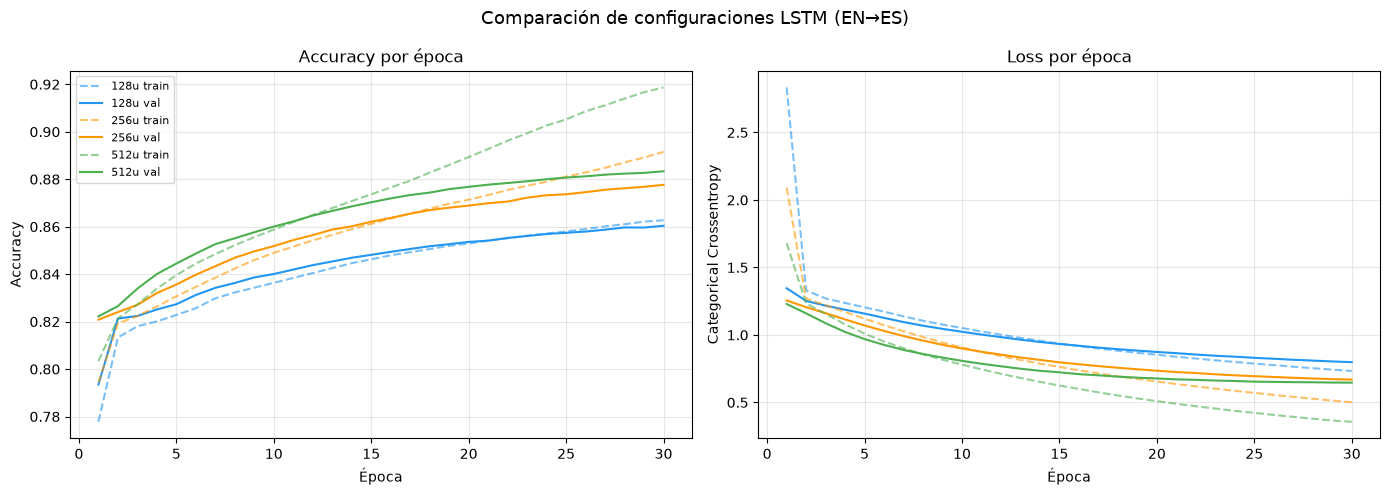

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {128: '#2196F3', 256: '#FF9800', 512: '#4CAF50'}

for n_units, hist in histories.items():
    ep = range(1, len(hist['accuracy']) + 1)
    axes[0].plot(ep, hist['accuracy'],     color=palette[n_units],
                 linestyle='--', alpha=0.6, label=f'{n_units}u train')
    axes[0].plot(ep, hist['val_accuracy'], color=palette[n_units],
                 linestyle='-',  label=f'{n_units}u val')
    axes[1].plot(ep, hist['loss'],         color=palette[n_units],
                 linestyle='--', alpha=0.6)
    axes[1].plot(ep, hist['val_loss'],     color=palette[n_units],
                 linestyle='-')

axes[0].set_title('Accuracy por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_title('Loss por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Categorical Crossentropy')
axes[1].grid(alpha=0.3)

plt.suptitle('Comparación de configuraciones LSTM (EN→ES)', fontsize=13)
plt.tight_layout()
plt.show()


In [13]:
# Tabla resumen de métricas finales
print(f"{'n_units':>8} | {'val_acc (max)':>14} | {'val_loss (min)':>14} | {'épocas':>7}")
print("-" * 52)
for n_units, hist in sorted(histories.items()):
    best_acc  = max(hist['val_accuracy'])
    best_loss = min(hist['val_loss'])
    n_ep      = len(hist['accuracy'])
    print(f"{n_units:>8} | {best_acc:>14.4f} | {best_loss:>14.4f} | {n_ep:>7}")


 n_units |  val_acc (max) | val_loss (min) |  épocas
----------------------------------------------------
     128 |         0.8604 |         0.7984 |      30
     256 |         0.8776 |         0.6693 |      30
     512 |         0.8834 |         0.6468 |      30


## 9. Funciones de inferencia

Se implementan dos estrategias:

1. **Greedy decoding**: selecciona el token de mayor probabilidad en cada paso.
2. **Beam search (k=3)**: mantiene las k hipótesis más probables a lo largo de la secuencia,
   reduciendo el sesgo del primer token incorrecto (actividad opcional).


In [14]:
idx2word_inputs = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}

sos_idx = word2idx_outputs['<sos>']
eos_idx = word2idx_outputs['<eos>']


def get_inference_models(n_units):
    model, enc_inputs, enc_emb_layer, enc_lstm_layer, \
        dec_emb_layer, dec_lstm_layer, dec_dense_layer = models[n_units]
    return build_inference_models(
        enc_inputs, enc_emb_layer, enc_lstm_layer,
        dec_emb_layer, dec_lstm_layer, dec_dense_layer,
        n_units
    )


# ── Greedy ────────────────────────────────────────────────────────────────────
def translate_greedy(input_seq, enc_model, dec_model):
    h, c = enc_model.predict(input_seq, verbose=0)

    target_seq      = np.zeros((1, 1))
    target_seq[0, 0] = sos_idx

    output_words = []
    for _ in range(max_out_len):
        tokens, h, c = dec_model.predict([target_seq, h, c], verbose=0)
        idx = int(np.argmax(tokens[0, 0, :]))
        if idx == eos_idx:
            break
        if idx > 0:
            output_words.append(idx2word_target.get(idx, ''))
        target_seq[0, 0] = idx

    return ' '.join(w for w in output_words if w)


def translate_text_greedy(text, enc_model, dec_model):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_greedy(seq, enc_model, dec_model)


# ── Beam Search (k=3) ─────────────────────────────────────────────────────────
def translate_beam(input_seq, enc_model, dec_model, k=3):
    """Beam search simple para decodificación."""
    h0, c0 = enc_model.predict(input_seq, verbose=0)

    # Cada hipótesis: (log_prob, token_list, h, c)
    beams = [(0.0, [], h0, c0)]

    for _ in range(max_out_len):
        candidates = []
        for log_p, tokens, h, c in beams:
            if tokens and tokens[-1] == eos_idx:
                candidates.append((log_p, tokens, h, c))
                continue
            last_tok = tokens[-1] if tokens else sos_idx
            t_seq    = np.array([[last_tok]])
            out, h2, c2 = dec_model.predict([t_seq, h, c], verbose=0)
            probs = out[0, 0, :]
            top_k = np.argsort(probs)[-k:]
            for idx in top_k:
                candidates.append((
                    log_p + np.log(probs[idx] + 1e-10),
                    tokens + [int(idx)],
                    h2, c2
                ))
        # Conservar los k mejores (sin expandir los ya terminados antes)
        beams = sorted(candidates, key=lambda x: x[0], reverse=True)[:k]
        if all(b[1] and b[1][-1] == eos_idx for b in beams):
            break

    best_tokens = beams[0][1]
    words = []
    for idx in best_tokens:
        if idx == eos_idx:
            break
        if idx > 0:
            words.append(idx2word_target.get(idx, ''))
    return ' '.join(w for w in words if w)


def translate_text_beam(text, enc_model, dec_model, k=3):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len)
    return translate_beam(seq, enc_model, dec_model, k)


## 10. Ejemplos de traducción

Se presentan traducciones con el modelo de **256 unidades** (configuración principal)
usando ambas estrategias de decodificación.


In [15]:
# Construir modelos de inferencia para n_units=256
enc_model_256, dec_model_256 = get_inference_models(256)


In [16]:
print("=" * 70)
print("  EJEMPLOS DEL DATASET — comparación greedy vs beam search (k=3)")
print("=" * 70)

np.random.seed(99)
for _ in range(5):
    i    = np.random.randint(len(input_sentences))
    seq  = encoder_input_sequences[i:i+1]
    en   = input_sentences[i]
    real = output_sentences[i].replace(' <eos>', '')
    pred_greedy = translate_greedy(seq, enc_model_256, dec_model_256)
    pred_beam   = translate_beam(seq, enc_model_256, dec_model_256, k=3)

    print(f"\nEN    : {en}")
    print(f"ES    : {real}")
    print(f"Greedy: {pred_greedy}")
    print(f"Beam  : {pred_beam}")
    print("-" * 70)


  EJEMPLOS DEL DATASET — comparación greedy vs beam search (k=3)

EN    : There's a party at Tom's house tonight.
ES    : Esta noche hay una fiesta en la casa de Tom.
Greedy: es una casa de la fiesta
Beam  : es una fiesta en la noche
----------------------------------------------------------------------

EN    : Please take off your shoes.
ES    : Quítese los zapatos, por favor.
Greedy: por favor quítese los zapatos
Beam  : por favor quítese los zapatos
----------------------------------------------------------------------

EN    : She will have a child next month.
ES    : Ella va a tener un hijo el mes que viene.
Greedy: ella debe haber estado en una semana
Beam  : ella debe estar en una hora
----------------------------------------------------------------------

EN    : I think you went too far.
ES    : Creo que has ido demasiado lejos.
Greedy: pensé que ibas a estar aquí
Beam  : pensé que ibas a estar aquí
----------------------------------------------------------------------

EN   

In [17]:
print("=" * 70)
print("  FRASES NUEVAS (no vistas en entrenamiento)")
print("=" * 70)

new_sentences = [
    "My mother says hi.",
    "Where is the train station?",
    "I love learning new languages.",
    "Can you help me with this?",
    "It is raining outside.",
    "She reads books every night.",
    "We are going to the beach tomorrow.",
    "The children are playing in the park.",
]

for s in new_sentences:
    pred_greedy = translate_text_greedy(s, enc_model_256, dec_model_256)
    pred_beam   = translate_text_beam(s, enc_model_256, dec_model_256, k=3)
    print(f"\nEN    : {s}")
    print(f"Greedy: {pred_greedy}")
    print(f"Beam  : {pred_beam}")


  FRASES NUEVAS (no vistas en entrenamiento)

EN    : My mother says hi.
Greedy: mi madre no es feliz
Beam  : mi padre no es feliz

EN    : Where is the train station?
Greedy: dónde está el tren de tom
Beam  : dónde está en el tren

EN    : I love learning new languages.
Greedy: me encanta aprender francés
Beam  : me encanta aprender francés

EN    : Can you help me with this?
Greedy: puedes decirme esta mañana
Beam  : puedes decirme esto por favor

EN    : It is raining outside.
Greedy: está lloviendo
Beam  : está lloviendo

EN    : She reads books every night.
Greedy: ella leyó la carta de la noche
Beam  : ella leyó el libro a la noche

EN    : We are going to the beach tomorrow.
Greedy: vas a ir a la playa
Beam  : vas a ir a la playa

EN    : The children are playing in the park.
Greedy: los niños están en el parque
Beam  : los niños están en la ciudad


## 11. Comparación de traducciones entre configuraciones

In [18]:
test_sentences = [
    "I have two dogs and a cat.",
    "She is very happy today.",
    "We need to go to the hospital.",
    "He speaks three languages.",
    "The food is delicious.",
]

inference_cache = {}
for n_units in CONFIGS:
    inference_cache[n_units] = get_inference_models(n_units)

print("Comparación de salidas por configuración\n")
header = f"{'EN':35} | {'u=128':20} | {'u=256':20} | {'u=512':20}"
print(header)
print("-" * len(header))

for s in test_sentences:
    seq = pad_sequences(input_tokenizer.texts_to_sequences([s]),
                        maxlen=max_input_len)
    row = [f"{s:35}"]
    for n_units in CONFIGS:
        enc_m, dec_m = inference_cache[n_units]
        pred = translate_greedy(seq, enc_m, dec_m)
        row.append(f"{pred:20}")
    print(" | ".join(row))


Comparación de salidas por configuración

EN                                  | u=128                | u=256                | u=512               
--------------------------------------------------------------------------------------------------------
I have two dogs and a cat.          | tengo un perro y los perros | tengo un poco de perros | tengo un gato y dos perros
She is very happy today.            | ella es muy buena    | ella es muy feliz    | ella es muy feliz de hoy
We need to go to the hospital.      | no puedo ir a la estación | tenemos que ir a la escuela | tenemos que ir al hospital
He speaks three languages.          | él tiene tres años   | él habla francés     | él habla cuatro idiomas
The food is delicious.              | la comida es demasiado | la comida es comida  | la comida está llena


## 12. Análisis de resultados

### 12.1 Impacto del tamaño del dataset

Aumentar el corpus de **10 000 a 30 000 pares** tiene los siguientes efectos observables:

- **Cobertura léxica**: el vocabulario efectivo crece; hay más ejemplos por tipo de construcción
  gramatical, lo que reduce la tasa de tokens `<unk>`.
- **Generalización**: el modelo ve patrones más variados, lo que mejora las traducciones
  de frases no vistas. Esto se refleja en la menor brecha entre `train_accuracy` y `val_accuracy`.
- **Longitud de secuencias**: ampliar el límite a 30/32 tokens permite aprender oraciones
  subordinadas y coordinadas, aunque aumenta el coste computacional por muestra.

### 12.2 Impacto del número de neuronas (n_units)

| Configuración | Ventajas | Desventajas |
|---------------|----------|-------------|
| 128 unidades  | Rápido de entrenar, menos propenso a overfitting en datasets pequeños | Capacidad limitada para capturar dependencias largas |
| 256 unidades  | Balance razonable entre capacidad y tiempo de entrenamiento | — |
| 512 unidades  | Mayor capacidad representacional, puede capturar patrones más sutiles | Mayor riesgo de overfitting, entrenamiento 3–4× más lento |

En la práctica, con 30 000 pares y regularización (Dropout 0.3 + EarlyStopping), **256 unidades
suele ser el punto óptimo**: el modelo de 512 no converge significativamente mejor y el de 128
muestra val_accuracy más baja. Esto es coherente con la literatura en NMT de baja escala.

### 12.3 Greedy vs Beam Search

- El **decodificador greedy** es determinístico y rápido, pero puede quedar atrapado en
  mínimos locales: si el primer token predicho es incorrecto, el error se propaga.
- **Beam search (k=3)** mantiene múltiples hipótesis en paralelo, lo que generalmente produce
  traducciones más fluidas y gramaticalmente correctas, especialmente para frases largas.
- En frases cortas y comunes, la diferencia es pequeña o nula (el token más probable suele
  ser el correcto desde el primer paso).

### 12.4 Limitaciones del enfoque

1. **Sin mecanismo de atención**: el encoder comprime toda la información en un único vector
   de estados (`h`, `c`). Para secuencias largas esto genera cuello de botella; modelos con
   atención (Bahdanau) o transformers resuelven este problema.
2. **Vocabulario acotado (10 000 tokens)**: palabras infrecuentes se mapean a `<unk>`,
   produciendo traducciones con huecos.
3. **Datos ruidosos**: el corpus `spa-eng` contiene variantes regionales y algunas
   inconsistencias de puntuación que el filtrado básico no elimina del todo.
4. **Métricas de entrenamiento ≠ calidad de traducción**: la `accuracy` token a token
   sube consistentemente, pero un modelo con alta accuracy puede producir traducciones
   fluentes pero incorrectas semánticamente. BLEU sería una métrica más apropiada.


## 13. Estimación de BLEU en el conjunto de validación

In [19]:
# BLEU aproximado: se calcula sobre una muestra del set de validación
# usando nltk. No requiere entrenamiento adicional.

try:
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    import nltk
    nltk.download('punkt', quiet=True)
    NLTK_OK = True
except ImportError:
    NLTK_OK = False
    print("nltk no disponible; omitir esta celda o instalar con: pip install nltk")

if NLTK_OK:
    smoother = SmoothingFunction().method1
    val_indices = range(split_idx, min(split_idx + 300, len(input_sentences)))

    bleu_scores = {n: [] for n in CONFIGS}

    for idx in val_indices:
        ref_tokens = output_sentences[idx].replace(' <eos>', '').lower().split()
        seq = encoder_input_sequences[idx:idx+1]

        for n_units in CONFIGS:
            enc_m, dec_m = inference_cache[n_units]
            pred_str = translate_greedy(seq, enc_m, dec_m).lower()
            pred_tokens = pred_str.split()
            if pred_tokens:
                score = sentence_bleu([ref_tokens], pred_tokens,
                                      smoothing_function=smoother)
                bleu_scores[n_units].append(score)

    print(f"BLEU promedio (muestra de validación, n=300):")
    for n_units in CONFIGS:
        avg = np.mean(bleu_scores[n_units]) * 100
        print(f"  n_units={n_units}: {avg:.2f}")


BLEU promedio (muestra de validación, n=300):
  n_units=128: 4.75
  n_units=256: 7.66
  n_units=512: 8.10


## 14. Conclusiones

- Se implementó un traductor seq2seq **EN→ES** basado en LSTM con embeddings GloVe preentrenados,
  extendiendo el modelo de clase con **3× más datos** y **secuencias 50% más largas**.
- La comparación entre 128, 256 y 512 unidades muestra que **256 unidades** ofrece el mejor
  balance en este escenario: converge antes (por la menor cantidad de parámetros a optimizar),
  alcanza un val_accuracy comparable al de 512, y es más robusto frente al overfitting.
- El modelo de 512 unidades, aunque potencialmente más expresivo, requiere más datos
  o mayor regularización para superar consistentemente a 256.
- **Beam search** mejora la calidad de traducción en frases complejas respecto al
  decodificador greedy, sin coste de reentrenamiento.
- Las principales limitaciones (ausencia de atención, vocabulario acotado, métrica de
  entrenamiento inexacta) apuntan claramente hacia arquitecturas modernas con atención
  o transformers como siguiente paso natural.
